# Approach
1. Join all the data together
2. Handling missing-ness
3. Feature Creation
4. Feature Reduction
5. Train_Test_Split
6. Encoding data
7. Training the models (kNN, SGDRegressor)
8. Model selection
9. Model Evaluation
10. Determining Business Impact
11. Conclusion and recommendations

## Packages used

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Report settings
pd.set_option('display.max_columns', None)
hs = 2 # dataframe head size - controls the number of rows to print; defaulted at 2 for compactness

# Joining all the data together

We start with importing all the files into DataFrames

In [3]:
list_filenames = ['Train_Demographics', 'Train_Claim', 'Train_Policy', 'Train_Vehicle', 'Traindata_with_Target']
list_df = []

for count, filename in enumerate(list_filenames):
    list_df.append(pd.read_csv(f'Datasets\\{filename}.csv'))
    list_df[count].name = filename

print(f'Checking file dimensions to ensure all are the same:')
for df in list_df:
    print(f'{df.name}: {df.shape}')

Checking file dimensions to ensure all are the same:
Train_Demographics: (28836, 10)
Train_Claim: (28836, 19)
Train_Policy: (28836, 10)
Train_Vehicle: (115344, 3)
Traindata_with_Target: (28836, 2)


"Train_Vehicle" has too many rows - this is because the data has been "pre-melted" and so we must pivot the data to give us the right dimension

In [4]:
# Checking to see how we should pivot the data
list_index = list_filenames.index('Train_Vehicle')
df = list_df[list_index]
df.head(hs)

,CustomerID,VehicleAttribute,VehicleAttributeDetails
0,Cust20179,VehicleID,Vehicle8898
1,Cust21384,VehicleModel,Malibu


In [5]:
# We need to pivot the data by 'VehicleAttribute' to retrieve its features
df = df.pivot(index='CustomerID',columns='VehicleAttribute', values='VehicleAttributeDetails')
print(df.shape)
list_df[list_index] = df
df.head(hs)

(28836, 4)


VehicleAttribute,VehicleID,VehicleMake,VehicleModel,VehicleYOM
CustomerID,,,,
Cust10000,Vehicle26917,Audi,A5,2008
Cust10001,Vehicle15893,Audi,A5,2006


Now that all datasets are of a similar structure, we can join the datasets.
We start by assigning "CustomerID" as the index for these dataframes - note that this means that we have made the decision that CustomerID is not correlated with ReportedFraud.

In [6]:
# Assigning 'CustomerID' as the index for all dataframes
for df in list_df:
    if df.index.name != 'CustomerID': df.set_index('CustomerID', inplace=True)

# Joining the dataframes to the first dataframe
df_joined = list_df[0].join(list_df[1:], how='left')
print(f'Combined dataset size: {df_joined.shape}')
df_joined.head(hs)

Combined dataset size: (28836, 41)


,InsuredAge,InsuredZipCode,InsuredGender,InsuredEducationLevel,InsuredOccupation,InsuredHobbies,CapitalGains,CapitalLoss,Country,DateOfIncident,TypeOfIncident,TypeOfCollission,SeverityOfIncident,AuthoritiesContacted,IncidentState,IncidentCity,IncidentAddress,IncidentTime,NumberOfVehicles,PropertyDamage,BodilyInjuries,Witnesses,PoliceReport,AmountOfTotalClaim,AmountOfInjuryClaim,AmountOfPropertyClaim,AmountOfVehicleDamage,InsurancePolicyNumber,CustomerLoyaltyPeriod,DateOfPolicyCoverage,InsurancePolicyState,Policy_CombinedSingleLimit,Policy_Deductible,PolicyAnnualPremium,UmbrellaLimit,InsuredRelationship,VehicleID,VehicleMake,VehicleModel,VehicleYOM,ReportedFraud
CustomerID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Cust10000,35,454776,MALE,JD,armed-forces,movies,56700,-48500,India,2015-02-03,Multi-vehicle Collision,Side Collision,Total Loss,Police,State7,City1,Location 1311,17,3,?,1,0,?,65501,13417,6071,46013,119121,49,1998-10-25,State1,100/300,1000,1632.73,0,not-in-family,Vehicle26917,Audi,A5,2008,N
Cust10001,36,454776,MALE,JD,tech-support,cross-fit,70600,-48500,India,2015-02-02,Multi-vehicle Collision,Side Collision,Total Loss,Police,State7,City5,Location 1311,10,3,YES,2,1,YES,61382,15560,5919,39903,119122,114,2000-11-15,State1,100/300,1000,1255.19,0,not-in-family,Vehicle15893,Audi,A5,2006,N


In [7]:
print(df_joined.columns)

Index(['InsuredAge', 'InsuredZipCode', 'InsuredGender',
       'InsuredEducationLevel', 'InsuredOccupation', 'InsuredHobbies',
       'CapitalGains', 'CapitalLoss', 'Country', 'DateOfIncident',
       'TypeOfIncident', 'TypeOfCollission', 'SeverityOfIncident',
       'AuthoritiesContacted', 'IncidentState', 'IncidentCity',
       'IncidentAddress', 'IncidentTime', 'NumberOfVehicles', 'PropertyDamage',
       'BodilyInjuries', 'Witnesses', 'PoliceReport', 'AmountOfTotalClaim',
       'AmountOfInjuryClaim', 'AmountOfPropertyClaim', 'AmountOfVehicleDamage',
       'InsurancePolicyNumber', 'CustomerLoyaltyPeriod',
       'DateOfPolicyCoverage', 'InsurancePolicyState',
       'Policy_CombinedSingleLimit', 'Policy_Deductible',
       'PolicyAnnualPremium', 'UmbrellaLimit', 'InsuredRelationship',
       'VehicleID', 'VehicleMake', 'VehicleModel', 'VehicleYOM',
       'ReportedFraud'],
      dtype='object')


# Checking labels for potential class imbalance

Percentage of Customers with Reported Fraud: 27.0%


<AxesSubplot:xlabel='ReportedFraud'>

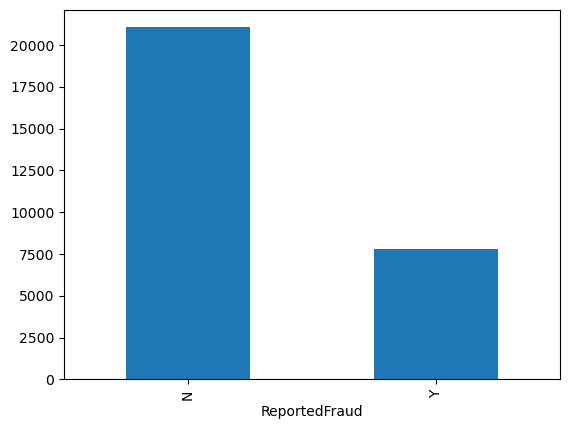

In [8]:
df_grouped = df_joined.groupby(['ReportedFraud'])['InsurancePolicyNumber'].count()

print(f'Percentage of Customers with Reported Fraud: {round((df_grouped["Y"]/df_grouped.sum())*100, 2)}%')

df_grouped.plot.bar()

As we can see, we do have some class imbalance here.
Instead of oversampling the minority class, however, we will deal with it by choosing techniques that are either less impacted by imbalance (e.g. MLPClassifier) or one that has the in-built ability in sklearn to correct this through weighting (e.g. LogisticRegression)

# Dealing with missing data
## Finding missing data
 - We know from the data descriptions that there are missing data
     - InsuredGender: NaN
     - ContractType: "NA" --> this field does not exist in dataset
     - TypeOfCollission: "?"
     - IncidentTime: -5
     - PropertyDamage: "?"
     - Witnesses: "MISSINGVALUE"
     - PoliceReport: "?"
     - AmountOfTotalClaim: "MISSEDDATA"
     - VehicleAttributeDetails: "???"
 - We could have determined the above by calling df.value_counts() for each column of the dataframe, but we have excluded it here for compactness of the report
 - While some of the missing data will be useful to capture as additional information, we will first cast all missing data to the np.NaN type

In [9]:
# We first get a feel for how many columns have an actual 'NaN' as missing values
df_missing = pd.Series(df_joined.isnull().sum())
print(df_missing[df_missing>0])

InsuredGender    30
Country           2
dtype: int64


In [10]:
# Replacing the only numerical "missing" data first
df_joined['IncidentTime'].replace(-5, np.NaN, inplace=True)

# Replacing all the missing values that are populated with strings
missing_values = ['MISSINGVALUE', 'MISSEDDATA', '?', '???']
df_joined.replace(missing_values, np.NaN, inplace=True)

df_missing = pd.Series(df_joined.isnull().sum())
print(df_missing[df_missing>0])

InsuredGender            30
Country                   2
TypeOfCollission       5162
IncidentTime             31
PropertyDamage        10459
Witnesses                46
PoliceReport           9805
AmountOfTotalClaim       50
VehicleMake              50
dtype: int64


## Dealing with missingness from a few small datapoints
The following features have missing data that consists of only a fraction of the total dataset: <br> InsuredGender, Country, IncidentTime, Witnesses, AmountOfTotalClaim, VehicleMake

As the change to dataset size is immaterialy, we can confidently drop those datapoints without affecting the analysis.

In [11]:
# Storing in a new dataframe for ease of re-running the cell
df_dropped = df_joined.dropna(subset=['InsuredGender', 'Country', 'IncidentTime', 'Witnesses', 
                                     'AmountOfTotalClaim', 'VehicleMake'])

print(f'We have reduced the total number of rows by: {len(df_joined) - len(df_dropped)}')
print(f'This has resulted in a {round((1-len(df_dropped)/len(df_joined))*100, 2)}% reduction in dataset size')

We have reduced the total number of rows by: 128
This has resulted in a 0.44% reduction in dataset size


## Dealing with material missingness
Missingness from other attributes cannot be dealt with in the same way, as this would affect the dataset too much.
Instead of ignoring the attribute, we will treat the 'Missing' data as a type of category, as we don't know whether the presence (or not) of the data is correlated to the ReportedFraud field. We can test this assumption later.

In [12]:
# Checking again to see which fields are most affected
df_missing = df_dropped.isnull().sum()
print(df_missing[df_missing>0])

TypeOfCollission     5139
PropertyDamage      10413
PoliceReport         9767
dtype: int64


# Feature Creation and Extraction
Examining some of the features, we can see that there is an opportunity to create new features that are more relevant for the analysis, namely:

- **CapitalProfit**: it may be easier for the model to correlate the net loss or gain of capital by combining the two columns
- **DayOfIncident**: as these are all historical dates, and the purpose of the model to classify existing and new customers, the actual "DateOfIncident" is less useful; however, the day of the week of the incident could be used
- **TimeToIncident**: similar to the above, we can extract how long it took how for an 'incident' to occur after the date the policy began
- **Policy_LowerSingleLimit** & **Policy_UpperSingleLimit**: 'Policy_CombinedSingleLimit' is a string value that appears to denote two separate values, which we can separate here

In [13]:
# Creating a new dataframe to help with re-running the cell
df = df_dropped.copy(deep=True)
df['CapitalProfit'] = df['CapitalGains'] + df['CapitalLoss']
df['DayOfIncident'] = pd.to_datetime(df['DateOfIncident']).dt.day_of_week
df['TimeToIncident'] = (pd.to_datetime(df['DateOfIncident'])-pd.to_datetime(df['DateOfPolicyCoverage'])).dt.days
df[['Policy_LowerSingleLimit', 'Policy_UpperSingleLimit']] = df['Policy_CombinedSingleLimit'].str.split('/', expand=True)
df.head(hs)

,InsuredAge,InsuredZipCode,InsuredGender,InsuredEducationLevel,InsuredOccupation,InsuredHobbies,CapitalGains,CapitalLoss,Country,DateOfIncident,TypeOfIncident,TypeOfCollission,SeverityOfIncident,AuthoritiesContacted,IncidentState,IncidentCity,IncidentAddress,IncidentTime,NumberOfVehicles,PropertyDamage,BodilyInjuries,Witnesses,PoliceReport,AmountOfTotalClaim,AmountOfInjuryClaim,AmountOfPropertyClaim,AmountOfVehicleDamage,InsurancePolicyNumber,CustomerLoyaltyPeriod,DateOfPolicyCoverage,InsurancePolicyState,Policy_CombinedSingleLimit,Policy_Deductible,PolicyAnnualPremium,UmbrellaLimit,InsuredRelationship,VehicleID,VehicleMake,VehicleModel,VehicleYOM,ReportedFraud,CapitalProfit,DayOfIncident,TimeToIncident,Policy_LowerSingleLimit,Policy_UpperSingleLimit
CustomerID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Cust10000,35,454776,MALE,JD,armed-forces,movies,56700,-48500,India,2015-02-03,Multi-vehicle Collision,Side Collision,Total Loss,Police,State7,City1,Location 1311,17.0,3,NaN,1,0,NaN,65501,13417,6071,46013,119121,49,1998-10-25,State1,100/300,1000,1632.73,0,not-in-family,Vehicle26917,Audi,A5,2008,N,8200,1,5945,100,300
Cust10001,36,454776,MALE,JD,tech-support,cross-fit,70600,-48500,India,2015-02-02,Multi-vehicle Collision,Side Collision,Total Loss,Police,State7,City5,Location 1311,10.0,3,YES,2,1,YES,61382,15560,5919,39903,119122,114,2000-11-15,State1,100/300,1000,1255.19,0,not-in-family,Vehicle15893,Audi,A5,2006,N,22100,0,5192,100,300


# Dimensionality Reduction
Now that we have additional features extracted, we can begin the process of removing certain features that may be obviously redundant or similar:
 - **Country**: Examining the data, it suggests that we only have data belonging to 'India', so our model must either by relevant only to India, or it must classify independently of country; therefore, we can drop this
 - **DateOfIncident**: The exact historical date won't help us with future datapoints, and we have already extracted a feature from this
 - **IncidentState** and **IncidentAddress**: It is unlikely that we need the Address itself, and having the **IncidentZipCity** will already inform the **IncidentState**; therefore these two are redundant / synonymous
 - **AmountOfInjuryClaim, AmountOfPropertyClaim, AmountOfVehicleDamage**: These are all the component parts of **AmountOfTotalClaim**, so we remove these
 - **InsurancePolicyNumber**: We can see that this is a unique identifier per customer, just like **CustomerID**, therefore we can drop this as we are already using **CustomerID** as the index
 - **Policy_CombinedSingleLimit**: We have split this out into two features, so we can remove this redundant column
 - **VehicleID**: The unique identifier for each vehicle covered is unlikely to be correlated with Fraud, so we can drop this

In [14]:
# Testing country
print(df['Country'].value_counts())

# Testing InsurancePolicyNumber
print(f'One InsurancePolicyNumber for each CustomerID? {len(df)==len(df["InsurancePolicyNumber"].unique())}')

# Testing VehicleID
print(f'One VehicleID for each CustomerID? {len(df)==len(df["VehicleID"].unique())}')

India    28708
Name: Country, dtype: int64
One InsurancePolicyNumber for each CustomerID? True
One VehicleID for each CustomerID? True


In [15]:
# Dropping columns
# Storing the result back into df_dropped to help with re-running this cell
df_dropped = df.drop(columns=['Country', 'DateOfIncident', 'IncidentState', 'IncidentAddress', 'AmountOfInjuryClaim'
                     ,'AmountOfPropertyClaim', 'AmountOfVehicleDamage', 'InsurancePolicyNumber'
                     , 'Policy_CombinedSingleLimit', 'VehicleID', 'DateOfPolicyCoverage'])

print(f'{df.shape[1] - df_dropped.shape[1]} columns dropped; new shape is: {df_dropped.shape}')

11 columns dropped; new shape is: (28708, 35)


# Feature Engineering - Encoding and Scaling the training data
Before we use a data mining technique on the data, we must first encode the categorical data into nominal values so that the techniques can digest the data; additionally, we should rescale the continuous data to avoid over-weighting one category over another due purely to their inherent scales (e.g. AmountOfTotalClaim in dollars vs Witnesses as integers)

**Encoding categorical data**
We have two approaches here:
1. Turn binary features into 1s and 0s using OrdinalEncoder - for missing values, we can use -1 as the ordinal value
2. Use One-of-K encoding for non-binary features
    - For features with high cardinality, we need to reduce the cardinality first

To avoid data leakage, we will not do this directly on the dataset now, but apply these transformations during cross-validation; however, we do need to understand which columns should have which types of data.

In [16]:
# Determining the number of unique values in each feature in the training set
print('Number of unique values for each feature')
col_dict = {}
for col in df_dropped.columns:
    col_dict[col] = len(df_dropped[col].unique())

unique_vals = pd.Series(col_dict).sort_values()
unique_vals

Number of unique values for each feature


ReportedFraud                  2
InsuredGender                  2
Policy_UpperSingleLimit        3
InsurancePolicyState           3
PoliceReport                   3
Policy_LowerSingleLimit        3
BodilyInjuries                 3
PropertyDamage                 3
NumberOfVehicles               4
SeverityOfIncident             4
Witnesses                      4
TypeOfIncident                 4
TypeOfCollission               4
AuthoritiesContacted           5
InsuredRelationship            6
IncidentCity                   7
DayOfIncident                  7
InsuredEducationLevel          7
InsuredOccupation             14
VehicleMake                   14
InsuredHobbies                20
VehicleYOM                    21
IncidentTime                  24
VehicleModel                  39
InsuredAge                    46
CapitalGains                 338
CapitalLoss                  354
CustomerLoyaltyPeriod        479
InsuredZipCode               995
CapitalProfit               1224
Policy_Ded

**InsuredZipCode** presents a problem - this is categorical in nature, but its cardinality is too high to use one-hot-encoding on. We will need to reduce its cardinality by clustering the zipcodes into two groups:
- Two groups are chosen because it is useful for binarization
- We can also confirm that two groups is a good choice with visualising the dataset (this is impractical as we technically need to do this for every KFold of the Cross-Validation to avoid data leakage)

We will use KMeans++ as the technique for grouping this - while technically ZipCodes are categorical, we can use its numeric nature as well as an assumption that most ZipCodes are issued in geographical clusters. Ideally, we would translate ZipCodes to latitude-longitude coordinates, but due to time, that will be considered outside the scope of this project.

In [17]:
# The target column to use LabelBinarizer on
target_column = ['ReportedFraud']

# The columns to use OrdinalEncoder on
ordinal_columns = ['InsuredGender', 'PropertyDamage', 'PoliceReport', 'InsuredZipCode']

# The columns to use StandardScaler on
scaled_columns = ['InsuredAge', 'CapitalGains', 'CapitalLoss', 'IncidentTime', 'NumberOfVehicles', 'BodilyInjuries'
                 , 'Witnesses', 'AmountOfTotalClaim', 'CustomerLoyaltyPeriod', 'Policy_Deductible', 'PolicyAnnualPremium'
                 , 'UmbrellaLimit', 'VehicleYOM', 'CapitalProfit', 'TimeToIncident', 'Policy_LowerSingleLimit'
                 , 'Policy_UpperSingleLimit']

#columns_to_drop = []
columns_to_drop = ['VehicleModel', 'InsuredHobbies', 'InsuredOccupation', 'VehicleMake']

# The columns to use OneHotEncoder on
onehot_columns = list(set(df_dropped.columns) - set(ordinal_columns) - set(target_column) - set(scaled_columns) - set(columns_to_drop))

In [18]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, LabelBinarizer

# This is used so we don't attempt the same transformation on all the features
from sklearn.compose import make_column_transformer 

In [19]:
def transform_dataset(df):
    
    # Grouping the ZipCodes into the two major groupings
    # We group into two clusters to simplify the 
    zipcodes = df['InsuredZipCode'].to_numpy().reshape(-1,1)
    kmeans_clf = KMeans(n_clusters=2, init='k-means++').fit(zipcodes)

    # The midpoint between both centroids is:
    mid_zipcode = abs(kmeans_clf.cluster_centers_[1]+kmeans_clf.cluster_centers_[0])/2
    
    df['InsuredZipCode'] = (df['InsuredZipCode'] >= mid_zipcode[0])*1
    
    # Encoding the target values
    # This cannot be added to the ColumnTransformer due to the transformer assuming LabelBinarizer \
    # has 3 inputs, not 2 
    y = LabelBinarizer().fit_transform(df[target_column]).ravel()
    df = df.drop(columns=target_column)
    
    # Dropping additional features as we test subsets
    df = df.drop(columns=columns_to_drop)
    
    # Encoding missing data as another type of value so that we don't accidentally remove some unknown correlation \
    # between missing values and the target labels
    df = df.replace(np.NaN, 'MISSING_DATA')
    
    transformer = make_column_transformer((StandardScaler(), scaled_columns)
                                          ,(OrdinalEncoder(), ordinal_columns)
                                          ,(OneHotEncoder(), onehot_columns)
                                          ,remainder='passthrough')    
    
    X = transformer.fit_transform(df)
    
    print(f'X Shape: {X.shape}')
    print(f'y Shape: {y.shape}')
    return X,y

# Preparing the training and test set parameters for the techniques
Note: due to the layout of the assignment, we will first do manual hyper-parameter optimisation using train_test_split. We will then use the sklearn provided tools of GridSearchCV, KFold, and cross_val_score in the final section where we compare the models

In [30]:
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.metrics import precision_recall_fscore_support, balanced_accuracy_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline

# Default n_splits=5 is used - this should be sufficient
inner_cv = KFold(shuffle=True) 

# We double the outer cv splits as we have a small dataset and can afford the calculations
outer_cv = KFold(n_splits=10, shuffle=True)

In [21]:
df_train, df_test = train_test_split(df_dropped, test_size=0.33, shuffle=True)

X_train, y_train = transform_dataset(df_train)
X_test, y_test = transform_dataset(df_test)

X Shape: (19234, 68)
y Shape: (19234,)
X Shape: (9474, 68)
y Shape: (9474,)


In [41]:
# helper function to show performance metrics
def show_performance_metrics(y_test, y_pred, clf):
    print(f'Balanced Accuracy is: {balanced_accuracy_score(y_test, y_pred)}')
    print(f'Precision and Recall are: {precision_recall_fscore_support(y_test, y_pred, average="weighted")[:2]}')
    
    cm = confusion_matrix(y_test, y_pred, normalize='pred')
    conf_matrix = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
    conf_matrix.plot()
    plt.show()

# Technique 1: LogisticRegression
This technique has been chosen for its speed of calculation as well as its ability to deal with class imbalance easily through the sklearn implementation


## Initial hyper-parameter selection and model training

In [23]:
from sklearn.linear_model import LogisticRegression

Balanced Accuracy is: 0.7222992236347248
Precision and Recall are: (0.7736430870885717, 0.7652522693687989)


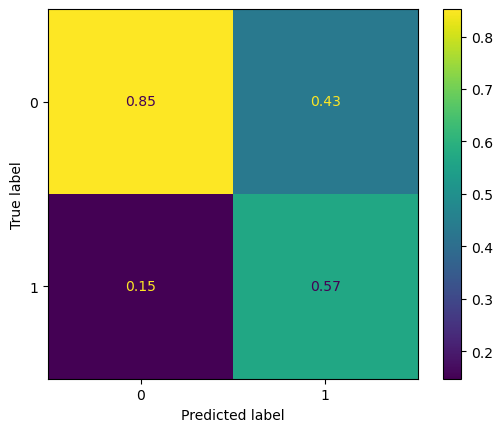

In [42]:
#%%timeit -n1 -r1

# We use class_weight='balanced' to help adjust for the imbalance in the target labels
# We use max_iter = 100 as the default
# We use solver = 'liblinear' as the sklearn documentaton indicates that this technique \
# ...is suitable for smaller datasets

lgr_clf = LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')
lgr_model = lgr_clf.fit(X_train, y_train)
y_pred = lgr_model.predict(X_test)

show_performance_metrics(y_test, y_pred, lgr_clf)

## Tuning hyper-parameters using GridSearch and Cross Validation (inner only)
 - We will use GridSearchCV to optimise for this training set
 - Cross Validation is part of this process, but to preserve the assessment structure, we will implement Nested CV later and only use one 'layer' of CV here

In [47]:
from sklearn.preprocessing import PolynomialFeatures
#degree = 10
#basisfunc_poly = PolynomialFeatures()
logreg_pipe = make_pipeline(PolynomialFeatures(degree=1), LogisticRegression(class_weight='balanced', solver='liblinear'))

params = {'polynomialfeatures__degree' : [1, 2]
        ,'logisticregression__max_iter' : [100]}

print(logreg_pipe)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=1)),
                ('logisticregression',
                 LogisticRegression(class_weight='balanced',
                                    solver='liblinear'))])


Balanced Accuracy is: 0.8197437151681723
Precision and Recall are: (0.844390089089689, 0.8270002111040743)


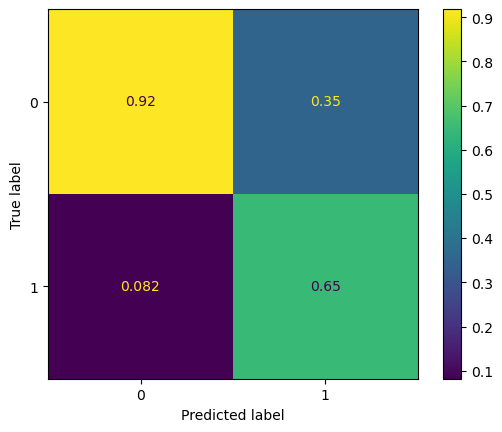

In [48]:
logreg_clf = GridSearchCV(logreg_pipe, param_grid = params)
logreg_model = logreg_clf.fit(X_train, y_train)
y_pred = logreg_model.predict(X_test)
show_performance_metrics(y_test, y_pred, logreg_clf)

In [ ]:
list_iters = np.arange(100, 600, 100, dtype='int16')
#print(list_iters)

#log_reg = LogisticRegression(class_weight='balanced', )
param_grid = {'max_iter' : list_iters
             ,'solver' : ['liblinear', 'lbfgs']}

log_reg = LogisticRegression(class_weight='balanced', solver='liblinear')
lgr_clf = GridSearchCV(log_reg, param_grid = param_grid)
lgr_model = lgr_clf.fit(X_train, y_train)
y_pred = lgr_model.predict(X_test)

#print(lgr_clf.best_estimator_)
#print(lgr_clf.best_score_)

print(f'Balanced Accuracy is: {balanced_accuracy_score(y_test, y_pred)}')
print(f'Precision and Recall are: {precision_recall_fscore_support(y_test, y_pred, average="weighted")[:2]}')
show_conf_matrix(y_test, y_pred)

# Technique 2: Neural Network

In [ ]:
from sklearn.neural_network import MLPClassifier

In [ ]:
#%%timeit -n1 -r1

mlp_clf = MLPClassifier(hidden_layer_sizes = 200, activation='logistic', solver='sgd', learning_rate='adaptive', max_iter=400)
mlp_model = mlp_clf.fit(X_train, y_train)
y_pred = mlp_model.predict(X_test)

print(f'Balanced Accuracy is: {balanced_accuracy_score(y_test, y_pred)}')
print(f'Precision and Recall are: {precision_recall_fscore_support(y_test, y_pred, average="weighted")[:2]}')

show_conf_matrix(y_test, y_pred)

# Technique 3: kNN

In [ ]:
#%%timeit -n1 -r1
neighbours = round(X_train.shape[0]**0.5)

# We are using distance-weighted kNN to help combat imbalance in the dataset
knn_clf = KNeighborsClassifier(n_neighbors=neighbours, weights='distance')
knn_model = knn_clf.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)

print(f'Balanced Accuracy is: {balanced_accuracy_score(y_test, y_pred)}')
print(f'Precision and Recall are: {precision_recall_fscore_support(y_test, y_pred, average="weighted")[:2]}')
#print(f'ROC-AUC score is: {roc_auc_score(y_test, y_pred)}')

The model, with "default" initial k, has led to a model which can detect 93% ReportedFraud in the test set; however, this is offset by the fact that we are also mislabelling 14% of customers as fraudulent, when they are not.

## Manually tuning k
As we can see, the initial k is not leading to a high enough balanced accuracy score (i.e. balanced error rate is >> 5%), so we need to perform a GridSearch on the data to optimise k.
We should also combine this with cross-validation, though this will be applied at the end (as required by the assessment brief).

Finally, note that we are using the **Balanced Accuracy Score** for model evaluation, as this allows us to account for the imbalanced nature of the dataset; additionally, we are trying to find a balance between True Positives and False Positives, as we need to be mindful that the cost of losing a customer is also an impact on the business.

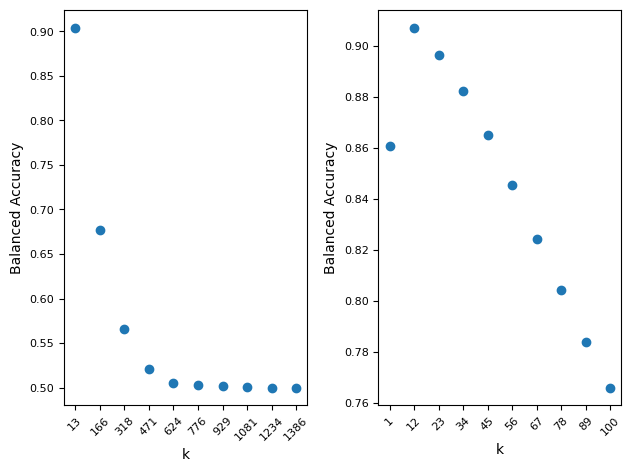

In [51]:
from sklearn.neighbors import KNeighborsClassifier
initial_k = X_train.shape[0]**0.5

fig, axes = plt.subplots(1,2)

for a in range(len(axes)):
    ax = axes[a]
    if a==0: k_neighbours = np.linspace(initial_k/10, initial_k*10, 10, dtype='int16')
    if a==1: k_neighbours = np.linspace(1, 100, 10, dtype='int16')
    
    balanced_accuracies = []
    
    for i,k in enumerate(k_neighbours):
        #print(f'k{i}: {k}')
        knn_clf = KNeighborsClassifier(n_neighbors=int(k), weights='distance')
        knn_model = knn_clf.fit(X_train, y_train)
        y_pred = knn_model.predict(X_test)

        balanced_accuracies.append(balanced_accuracy_score(y_test, y_pred))
    
    ax.scatter(k_neighbours, balanced_accuracies)
    ax.set_xlabel('k', size=10)
    ax.set_ylabel('Balanced Accuracy', size=10)
    ax.set_xticks(k_neighbours, labels=k_neighbours, rotation = 45)
    ax.tick_params(axis='both', labelsize=8)

plt.tight_layout(pad=1)
plt.show()

In [ ]:
show_conf_matrix(y_test, y_pred)

By testing multiple orders of magnitude, we can see that the best k in this instance is k=~10
However, we must be careful here, as this is a relatively small number for such a large dataset, which means we are at risk of overfitting this model.

We will fine-tune the hyper-parameters in sections further below in this report.